In [2]:
# librerias
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix,negativity,state_fidelity,Operator,concurrence,entropy
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke


from qiskit_dynamics import Solver, Signal
from qiskit_dynamics.backend import parse_backend_hamiltonian_dict

from qiskit import pulse
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import numpy as np
import random
import math
import sympy as sym

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")

In [3]:
import numpy as np
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

def plot_statevector_probabilities(statevector):
    probabilities = statevector.probabilities()
    num_qubits = int(np.log2(len(probabilities)))
    basis_states = [f"|{i:0{num_qubits}b}⟩" for i in range(2**num_qubits)]
    
    plt.figure(figsize=(12,5))
    plt.bar(basis_states, probabilities, color='royalblue', alpha=0.7)
    plt.xlabel('Computational basis states',fontsize=15)
    plt.ylabel('Probability',fontsize=15)
    # plt.title('Measurement Probabilities of Statevector',fontsize=15)
    plt.ylim(0, 0.8)
    plt.xticks(rotation=0,fontsize=16)
    plt.yticks(fontsize=14)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [5]:
def plot_statevector_probabilities_qudit(statevector, d=2):
    """
    Grafica probabilidades de un statevector de qudits.
    Usa etiquetas en base d (por defecto qubits: d=2).
    """
    probabilities = statevector.probabilities()
    dim = len(probabilities)
    
    # Número de qudits
    num_qudits = int(round(np.log(dim) / np.log(d)))
    
    # Etiquetas en base d (por ejemplo base=3 para qutrits)
    basis_states = []
    for i in range(dim):
        digits = np.base_repr(i, base=d).zfill(num_qudits)
        basis_states.append(f"|{digits}⟩")
    
    # Gráfico
    plt.figure(figsize=(12,5))
    plt.bar(basis_states, probabilities, color='royalblue')
    plt.xlabel(f'Computational basis states ',fontsize=20)
    plt.ylabel('Probability',fontsize=20)
    # plt.title(f'Measurement Probabilities of {num_qudits} qudits (d={d})',fontsize=20)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=0,fontsize=16)
    plt.yticks(fontsize=14)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [6]:
# Llamar fake backend
backend = FakeSherbrooke()

#configuracion de backend
propiedades = backend.properties()
configuracion = backend.configuration()


Hz = 1e9
# Definicion de la frecuencia de los qubits en GHz
w7   = configuracion.hamiltonian.get("vars").get("wq7")
w8   = configuracion.hamiltonian.get("vars").get("wq8")
w9   = configuracion.hamiltonian.get("vars").get("wq9")
# anamornicidad de los qubits en GHz
delta7 = configuracion.hamiltonian.get("vars").get("delta7")
delta8 = configuracion.hamiltonian.get("vars").get("delta8")
delta9 = configuracion.hamiltonian.get("vars").get("delta9")
# acoples en GHz
J78 = configuracion.hamiltonian.get("vars").get("jq7q8")
J89 = configuracion.hamiltonian.get("vars").get("jq8q9")
# fuerza de control en GHz
r0   =  configuracion.hamiltonian.get("vars").get("omegad7")
r1   =  configuracion.hamiltonian.get("vars").get("omegad8")
r2   =  configuracion.hamiltonian.get("vars").get("omegad9")
# tiempo de gate en ns
dt = backend.dt*1e9


v7 = w7 /(2*np.pi)
v8 = w8 /(2*np.pi)
v9 = w9 /(2*np.pi)
print(v7, v8, v9)

4.755587722216812 4.812531480182586 4.637614165110824


In [7]:
print(delta7, delta8, delta9)

-1.9540951675249636 -1.9688054129735373 -1.8387169285946419


In [8]:
backend.configuration().to_dict()["coupling_map"]

[[1, 0],
 [1, 2],
 [3, 2],
 [4, 3],
 [4, 15],
 [5, 4],
 [6, 5],
 [7, 6],
 [7, 8],
 [8, 9],
 [10, 9],
 [10, 11],
 [11, 12],
 [12, 13],
 [14, 0],
 [14, 18],
 [16, 8],
 [17, 12],
 [17, 30],
 [18, 19],
 [19, 20],
 [20, 33],
 [21, 20],
 [21, 22],
 [22, 15],
 [23, 22],
 [23, 24],
 [25, 24],
 [26, 16],
 [26, 25],
 [26, 27],
 [28, 27],
 [29, 28],
 [29, 30],
 [31, 30],
 [31, 32],
 [32, 36],
 [33, 39],
 [34, 24],
 [35, 28],
 [35, 47],
 [36, 51],
 [37, 38],
 [38, 39],
 [40, 39],
 [41, 40],
 [41, 53],
 [42, 41],
 [43, 34],
 [43, 42],
 [43, 44],
 [45, 44],
 [45, 46],
 [47, 46],
 [47, 48],
 [49, 48],
 [49, 50],
 [50, 51],
 [52, 37],
 [53, 60],
 [54, 45],
 [55, 49],
 [56, 52],
 [56, 57],
 [57, 58],
 [59, 58],
 [59, 60],
 [61, 60],
 [61, 62],
 [63, 62],
 [63, 64],
 [64, 54],
 [64, 65],
 [66, 65],
 [67, 66],
 [68, 55],
 [68, 67],
 [69, 68],
 [69, 70],
 [71, 58],
 [71, 77],
 [72, 62],
 [73, 66],
 [73, 85],
 [74, 70],
 [75, 76],
 [77, 76],
 [78, 77],
 [78, 79],
 [79, 91],
 [80, 79],
 [80, 81],
 [81, 72],

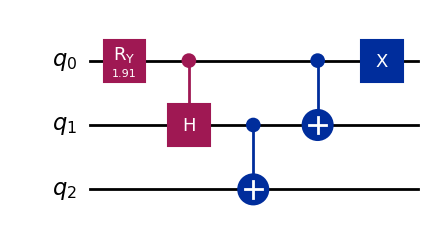

In [9]:
tetha = 2*np.acos(1/np.sqrt(3))
w = QuantumCircuit(3)
w.ry(tetha,0)
w.ch(0,1)
w.cx(1,2)
w.cx(0,1)
w.x(0)
w.draw("mpl")

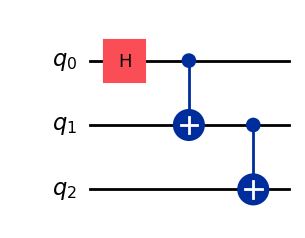

In [10]:
GHZ = QuantumCircuit(3)
GHZ.h(0)
GHZ.cx(0, 1)
GHZ.cx(1, 2)
GHZ.draw("mpl")

In [11]:
Statevector(GHZ).draw("latex")

<IPython.core.display.Latex object>

In [12]:
concurrence(partial_trace(Statevector(w),[0]))**2

np.float64(0.44444444444444425)

In [13]:
Statevector(w).draw("latex")

<IPython.core.display.Latex object>

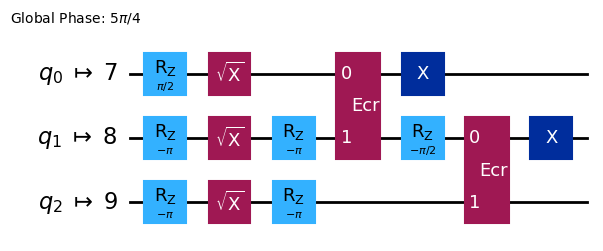

In [14]:
isa = transpile(GHZ,backend=backend,initial_layout=[7,8,9],optimization_level=3)
isa.draw("mpl",idle_wires=False)

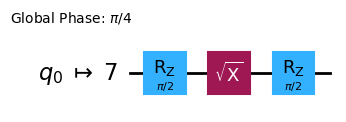

In [15]:
qc1 = QuantumCircuit(3)
qc1.h(0)
isa1 = transpile(qc1,backend=backend,initial_layout=[7,8,9],optimization_level=3)
isa1.draw("mpl",idle_wires=False)

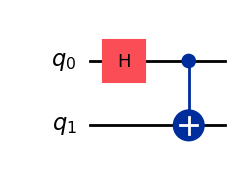

In [16]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)   
bell.draw("mpl")

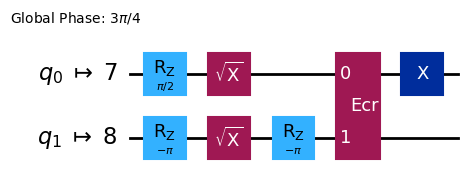

In [17]:
isa2 = transpile(bell, backend=backend, initial_layout=[7, 8], optimization_level=3)
isa2.draw("mpl",idle_wires=False)

In [18]:
for i in range(len(backend.defaults().to_dict()["cmd_def"])):
    lis = backend.defaults().to_dict()["cmd_def"][i]
    if lis["name"] == "ecr":
        lis["name"]
        print(lis["name"], "   ",  lis["qubits"],   i)

ecr     [1, 0] 0
ecr     [1, 2] 1
ecr     [3, 2] 2
ecr     [4, 3] 3
ecr     [4, 15] 4
ecr     [5, 4] 5
ecr     [6, 5] 6
ecr     [7, 6] 7
ecr     [7, 8] 8
ecr     [8, 9] 9
ecr     [10, 9] 10
ecr     [10, 11] 11
ecr     [11, 12] 12
ecr     [12, 13] 13
ecr     [14, 0] 14
ecr     [14, 18] 15
ecr     [16, 8] 16
ecr     [17, 12] 17
ecr     [17, 30] 18
ecr     [18, 19] 19
ecr     [19, 20] 20
ecr     [20, 33] 21
ecr     [21, 20] 22
ecr     [21, 22] 23
ecr     [22, 15] 24
ecr     [23, 22] 25
ecr     [23, 24] 26
ecr     [25, 24] 27
ecr     [26, 16] 28
ecr     [26, 25] 29
ecr     [26, 27] 30
ecr     [28, 27] 31
ecr     [29, 28] 32
ecr     [29, 30] 33
ecr     [31, 30] 34
ecr     [31, 32] 35
ecr     [32, 36] 36
ecr     [33, 39] 37
ecr     [34, 24] 38
ecr     [35, 28] 39
ecr     [35, 47] 40
ecr     [36, 51] 41
ecr     [37, 38] 42
ecr     [38, 39] 43
ecr     [40, 39] 44
ecr     [41, 40] 45
ecr     [41, 53] 46
ecr     [42, 41] 47
ecr     [43, 34] 48
ecr     [43, 42] 49
ecr     [43, 44] 50
ecr     [45,

C:\Users\PC\AppData\Local\Temp\ipykernel_20396\1390249828.py:1: DeprecationWarning: The defaults method and the PulseDefaults class have been deprecated as of qiskit-ibm-runtime 0.38.0 and will be removed no sooner than 3 months after the release date. IBM backends no longer support pulse gates and are no longer used to construct the backend target. 
  for i in range(len(backend.defaults().to_dict()["cmd_def"])):
C:\Users\PC\AppData\Local\Temp\ipykernel_20396\1390249828.py:2: DeprecationWarning: The defaults method and the PulseDefaults class have been deprecated as of qiskit-ibm-runtime 0.38.0 and will be removed no sooner than 3 months after the release date. IBM backends no longer support pulse gates and are no longer used to construct the backend target. 
  lis = backend.defaults().to_dict()["cmd_def"][i]


In [19]:
backend.defaults().to_dict()["cmd_def"][8]

C:\Users\PC\AppData\Local\Temp\ipykernel_20396\2139611261.py:1: DeprecationWarning: The defaults method and the PulseDefaults class have been deprecated as of qiskit-ibm-runtime 0.38.0 and will be removed no sooner than 3 months after the release date. IBM backends no longer support pulse gates and are no longer used to construct the backend target. 
  backend.defaults().to_dict()["cmd_def"][8]


{'name': 'ecr',
 'qubits': [7, 8],
 'sequence': [{'name': 'parametric_pulse',
   't0': 1072,
   'ch': 'd7',
   'label': 'Xp_d7',
   'pulse_shape': 'drag',
   'parameters': {'amp': (0.30013844608900425+0j),
    'beta': 0.2512346174627538,
    'duration': 256,
    'sigma': 64}},
  {'name': 'parametric_pulse',
   't0': 0,
   'ch': 'd8',
   'label': 'CR90p_d8_u16',
   'pulse_shape': 'gaussian_square',
   'parameters': {'amp': (0.03934520138323596+0.0001928205190067114j),
    'duration': 1072,
    'sigma': 64,
    'width': 816}},
  {'name': 'parametric_pulse',
   't0': 1328,
   'ch': 'd8',
   'label': 'CR90m_d8_u16',
   'pulse_shape': 'gaussian_square',
   'parameters': {'amp': (-0.03934520138323596-0.00019282051900670658j),
    'duration': 1072,
    'sigma': 64,
    'width': 816}},
  {'name': 'parametric_pulse',
   't0': 0,
   'ch': 'u16',
   'label': 'CR90p_u16',
   'pulse_shape': 'gaussian_square',
   'parameters': {'amp': (0.006928583766661819-0.2974765037423097j),
    'duration': 1072,

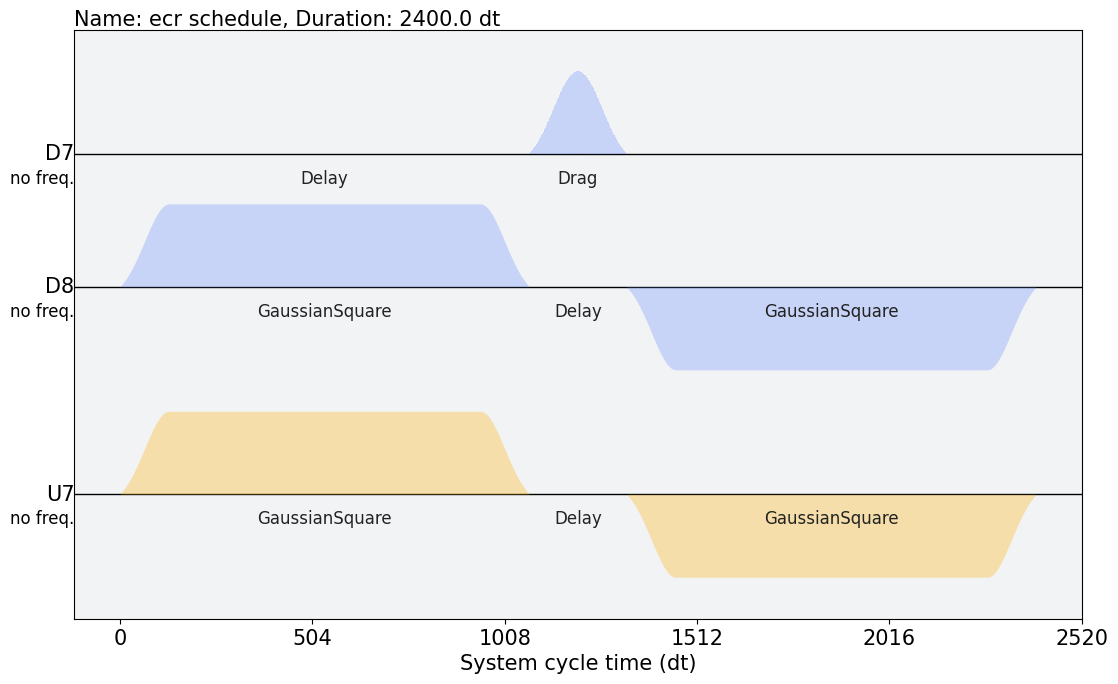

In [20]:
with pulse.build(name = "ecr schedule") as cxp:
    
    
    # pulse.play(pulse.Drag(duration= 160, sigma = 40, beta= 0.5786581700523524, amp=  -0.12418567946483217, angle=0.0), pulse.DriveChannel(0))
    pulse.delay(1072, pulse.DriveChannel(7))
    
    pulse.play(pulse.Drag(duration= 256, sigma = 64, beta=  0.5786581700523524, amp=  0.12418567946483217, angle=0.0), pulse.DriveChannel(7))
    
    # pulse.play(pulse.Drag(duration= 160, sigma = 40, beta=  -0.6658140461710471, amp= 0.07390084708127678, angle=0.0), pulse.DriveChannel(1))
    # pulse.delay(160, pulse.DriveChannel(1))
    pulse.play(pulse.GaussianSquare(duration= 1072,   sigma= 64, width= 816, amp= 0.05834410425763458, ),pulse.DriveChannel(8))
    
    pulse.delay(256,pulse.DriveChannel(8))
    pulse.play(pulse.GaussianSquare(duration= 1072,   sigma= 64, width= 816, amp= -0.05834410425763458, ),pulse.DriveChannel(8))
    
    # pulse.delay(160, pulse.ControlChannel(0))
    pulse.play(pulse.GaussianSquare(duration= 1072,   sigma= 64, width= 816, amp=  0.5120610220133731, ),pulse.ControlChannel(7))
    
    
    pulse.delay(256, pulse.ControlChannel(7))
    pulse.play(pulse.GaussianSquare(duration= 1072,   sigma= 64, width= 816, amp=   -0.5120610220133731, ),pulse.ControlChannel(7))

    pulse.ShiftPhase(1.5707963267948966, pulse.ControlChannel(8))
    
    # pulse.play(pulse.GaussianSquare(duration=22400, sigma=64, width= 22144, amp=-0.025), pulse.MeasureChannel(0))
    # pulse.play(pulse.GaussianSquare(duration=22400, sigma=64, width= 22144, amp= 0.04), pulse.MeasureChannel(1))
    
cxp.draw()
    

In [21]:
# Definir los operadores 
dim = 2
a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident = np.eye(dim, dtype=complex)
full_ident = np.eye(dim**2, dtype=complex)

N0 = np.kron(ident,np.kron(ident, N))
N1 = np.kron(ident,np.kron(N, ident))
N2 = np.kron(np.kron(N, ident),ident)

a0 = np.kron(ident,np.kron(ident, a))
a1 = np.kron(ident,np.kron(a, ident))
a2 = np.kron(np.kron(a, ident),ident)


a0dag = np.kron(ident,np.kron(ident, adag))
a1dag = np.kron(ident,np.kron(adag, ident))
a2dag = np.kron(np.kron(adag, ident),ident)

# Haniltoniano del sistema
static_ham = 2*np.pi*v7 * N0  +2*np.pi*v8 * N1  + 2*np.pi*v9* N2   + J78*(a0dag @ a1 +  a0 @ a1dag) + J89*(a1dag @ a2 +  a1 @ a2dag)

# Hamiltonianos de controles
H_drive7 =  r0 * (a0 + a0dag)
H_drive8 =  r1 * (a1 + a1dag)
H_drive9 =  r2 * (a2 + a2dag)
  

y0  = Statevector.from_label("000")

In [22]:
solver = Solver(
    static_hamiltonian=static_ham,
    hamiltonian_operators=[H_drive7, H_drive8, H_drive9, H_drive7, H_drive8],
    hamiltonian_channels=["d0", "d1", "d2", "u0", "u1"],
    channel_carrier_freqs= {"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
    dt=dt,
    array_library="jax",
)

In [24]:
def esque_wprofe(params):
    """Primer bloque
       t_0 : duración de los canales        d0,d1
       t_1 : duración del canal             u0
       A0  : Amplitude del primer pulso     d0
       A1  : Apmpliud del segundo pulso     d1
       A2  : Amplitud del pulsos de control U0
       Segundo bloque
       t_2 : duracion del canal             d2
       t_3 : duracion del mcanal            u1
       A3  : Amplitud del pulso             d2
       A4  : Amplitud del pulso             u1
       Tercer bloque
       t_4 : duración del canal             d0
       t_5 : duracion del canal             d1
       t_6 : duracion del canal             u0
       A5  : Amplitud del canal             d0
       A6  : Amplitud del canal             d1
       A7  : Amplitud del canal             u0 
       """
    t_0, t_1, t_2,t_3, t_4, t_5 ,A0, A1, A2, A3, A4, A5, A6, A7, A8, A9, A10, A11  = params


    # Convertir a enteros por requerimiento del backend
    t_0 = int(t_0)
    t_1 = int(t_1)
    t_2 = int(t_2)
    t_3 = int(t_3)
    t_4 = int(t_4)
    t_5 = int(t_5)
    
    

    with pulse.build(name="W Pulse") as kp:
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        d2 = pulse.DriveChannel(2)
        u0 = pulse.ControlChannel(0)
        u1 = pulse.ControlChannel(1)
        
        # pulse.shift_phase(p0,d0)
        pulse.play(pulse.Constant(t_0,A0),d0)
        pulse.play(pulse.Constant(t_0,A1),d1)
        pulse.play(pulse.Constant(t_0,A2),d2)
        
        pulse.delay(duration = 1+t_0, channel=u0)
        pulse.play(pulse.Constant(duration = t_1 , amp=A3), u0)
        
        pulse.delay( t_1 +1,d0)
        pulse.play(pulse.Constant(t_2,A4),d0)
        
        pulse.delay(t_1 +1, d1)
        pulse.play(pulse.Constant(t_2,A5),d1)
        
        pulse.delay(t_1 +1, d2)
        pulse.play(pulse.Constant(t_2,A6),d2)
        
        
        pulse.delay(t_0 + t_1 + 1 + 1 + t_2, u1)
        pulse.play(pulse.Constant(t_3,A7),u1)      #A7
        
        pulse.delay(t_3+1,d0)
        pulse.play(pulse.Constant(t_4,A8),d0)      #A8
        
        pulse.delay(t_3+1,d1)
        pulse.play(pulse.Constant(t_4,A9),d1)      #A9
        
        pulse.delay(t_3+1,d2)
        pulse.play(pulse.Constant(t_4,A10),d2)     #A10
        
        pulse.delay(1+t_2+1+t_3+t_4 +1,u0)
        pulse.play(pulse.Constant(t_5,A11),u0)     #A11 
        
        
    return kp

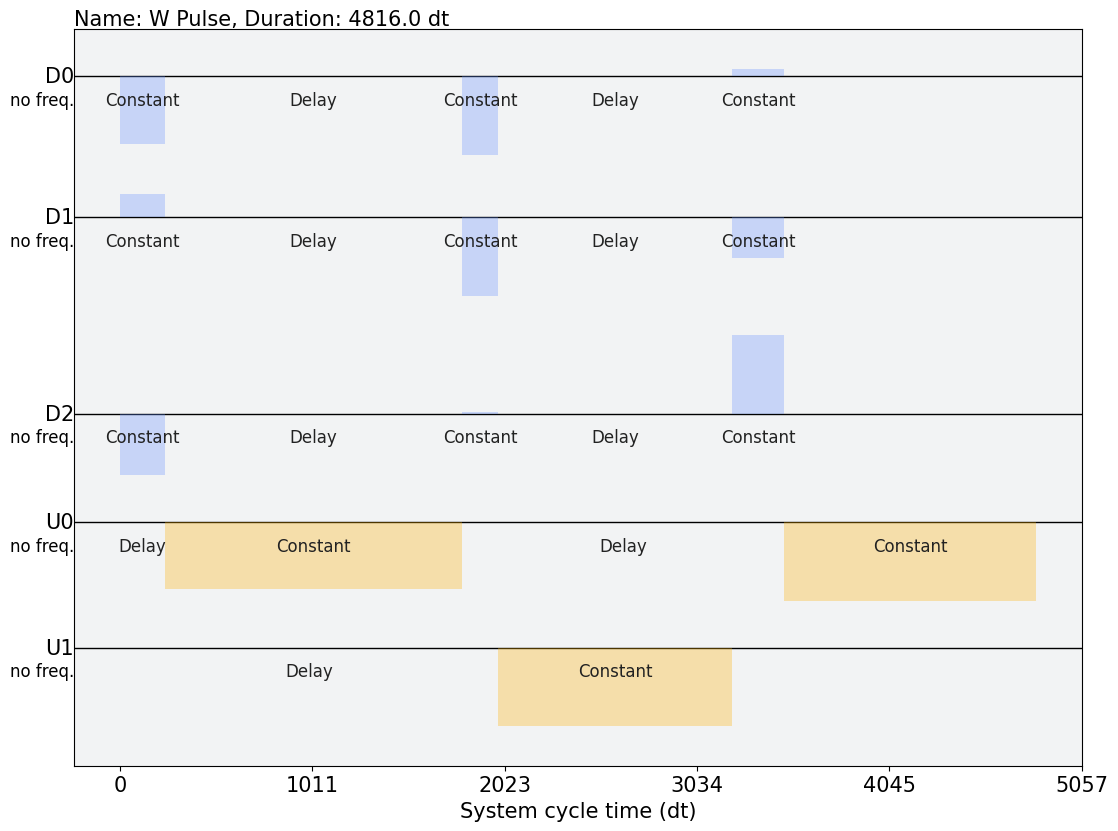

In [25]:
x = [ 2.34830783e+02,  1.56574174e+03,  1.87479735e+02,  1.22942236e+03,2.74196599e+02,  1.32352652e+03, 
     -2.04862473e-01,  2.53423969e-01,-6.75297508e-01,   # A0, A1, A2
     -5.11593803e-01,                                    # A3
     -2.36750884e-01, -8.53527417e-01,                   # A4, A5, A6
     2.33549100e-02,                                     # A7
     -4.44121784e-01,  8.66030588e-01,                   # A8, A9, A10
     -6.05000131e-01]                                    # A11 


x = [ 2.34830783e+02,  1.56574174e+03,  1.87479735e+02,  1.22942236e+03, 2.74196599e+02,  1.32352652e+03, 
     -2.04862473e-01, 2.53423969e-01,-6.75297508e-01,    # A0, A1, A2
     -5.11593803e-01,                                    # A3
     -2.36750884e-01,-8.53527417e-01, 2.33549100e-02,    # A4, A5, A6
     -8.53527417e-01,                                     # A7
      2.33549100e-02, -4.44121784e-01,  8.66030588e-01,   # A8, A9, A10
    -6.05000131e-01]                                      # A11 
# esto es bueno






esque_wprofe(x).draw()

In [26]:
def objective_w(x):
    signal = esque_wprofe(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-8,
        rtol=1e-9
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    
    conc_01 = concurrence(partial_trace(yf, [2]))**2
    conc_02 = concurrence(partial_trace(yf, [1]))**2  
    conc_12 = concurrence(partial_trace(yf, [0]))**2
    conc_function = conc_01 + conc_02 + conc_12
    
    cost = (
        10*(conc_01 - 0.4444444)**2 + 5*(conc_12 - conc_01)**2 + 8*(conc_02 -conc_01)**2 # Igualdad entre concurrencias
        + 5*(np.sqrt(conc_01) + np.sqrt(conc_02) + np.sqrt(conc_12) - 2)**2  # Suma ≈ 2

    )
    
    return np.sqrt(cost)
  

In [27]:
def objective(x):
    signal = esque_wprofe(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    return yf

In [28]:
objective_w(x)

np.float64(0.008536187738647723)

In [29]:
objective(x).draw("latex_source")

'(0.1134052212 + 0.5013088803 i) |000\\rangle+(-0.2180216912 - 0.0562312577 i) |001\\rangle+(0.0791347036 - 0.1985244479 i) |010\\rangle+(0.2269640703 + 0.2573454057 i) |011\\rangle+(0.0762989943 - 0.2321113255 i) |100\\rangle+(-0.4621581333 - 0.2633040603 i) |101\\rangle+(-0.0900290565 + 0.2008594117 i) |110\\rangle+(-0.2501544727 - 0.2609143129 i) |111\\rangle'

In [30]:
np.linalg.norm(objective(x))

np.float64(1.0)

In [31]:
concurrence(partial_trace(objective(x),[1]))**2

np.float64(0.44433607770354555)

In [32]:
concurrence(partial_trace(objective(x),[0]))**2

np.float64(0.44216636064613485)

In [33]:
concurrence(partial_trace(objective(x),[2]))**2

np.float64(0.4420094337566922)

In [34]:
objective(x).probabilities()

array([0.26417134, 0.05069541, 0.04567426, 0.11773935, 0.0596972 ,
       0.28291917, 0.04844973, 0.13065354])

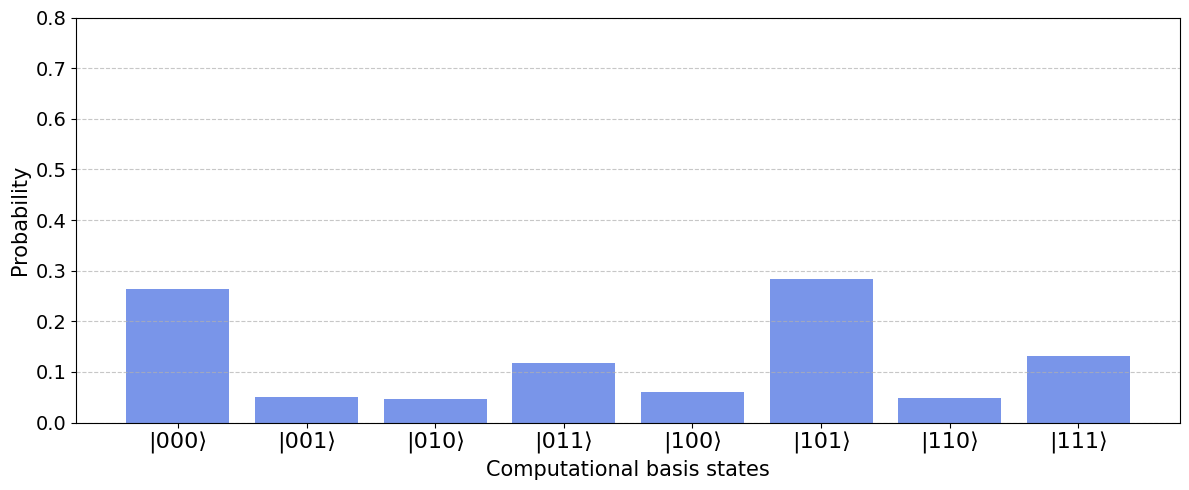

In [35]:
qc = QuantumCircuit(3)
qc.initialize(objective(x))


plot_statevector_probabilities(Statevector(qc))

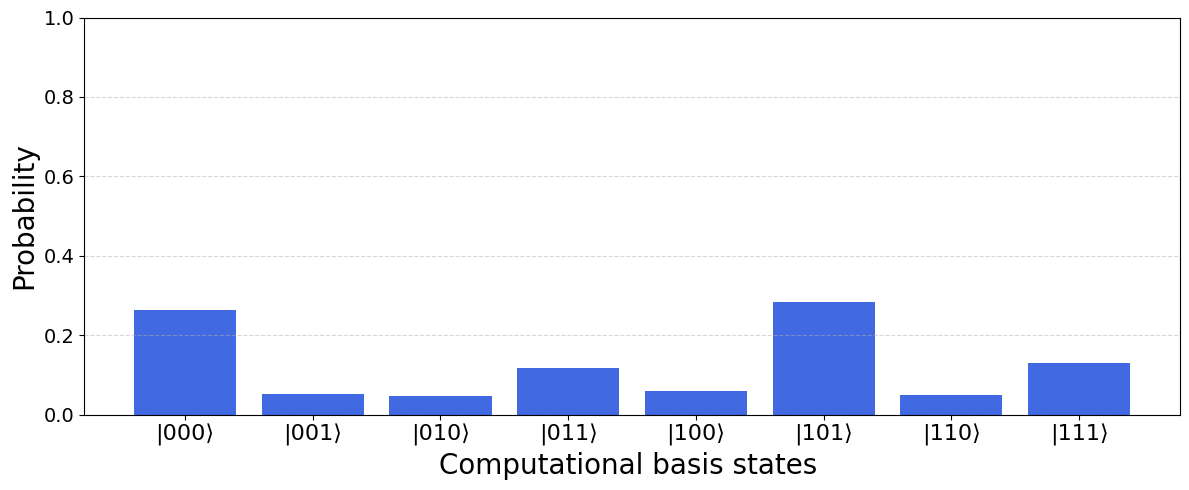

In [36]:
plot_statevector_probabilities_qudit(Statevector(qc), d=2)

In [21]:
def objective_w(x):
    signal = esque_wprofe(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-8,
        rtol=1e-9
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    
    conc_01 = concurrence(partial_trace(yf, [2]))**2
    conc_02 = concurrence(partial_trace(yf, [1]))**2  
    conc_12 = concurrence(partial_trace(yf, [0]))**2
    conc_function = conc_01 + conc_02 + conc_12
    
    cost = (
        100*(conc_01 - 0.4444444)**2 + 5*(conc_12 - conc_01)**2 + 5*(conc_02 -conc_01)**2 # Igualdad entre concurrencias
        + 2*(np.sqrt(conc_01) + np.sqrt(conc_02) + np.sqrt(conc_12) - 2)**2  # Suma ≈ 2

    )
    
    return np.sqrt(cost)
  
  

Matrices W

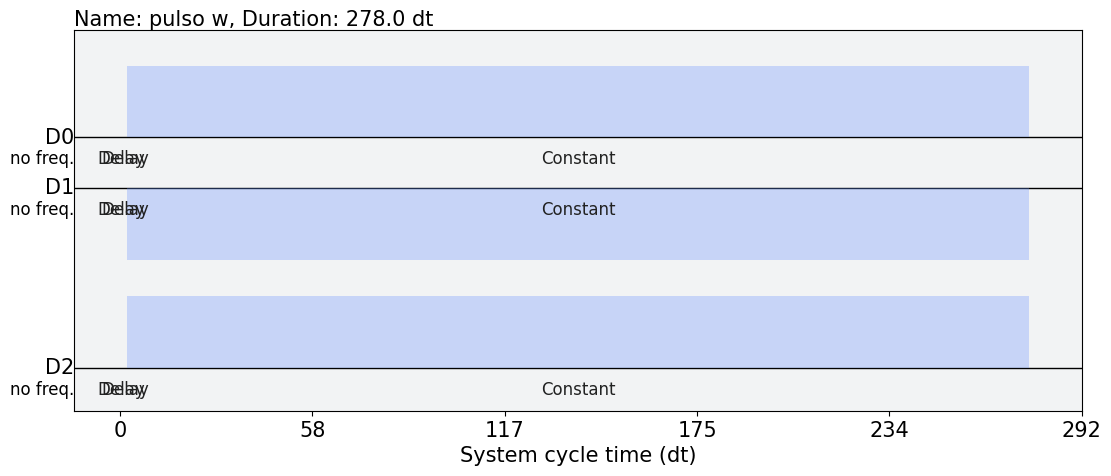

In [22]:
x = [ 2.34830783e+02,  1.56574174e+03,  1.87479735e+02,  1.22942236e+03, 2.74196599e+02,  1.32352652e+03, 
     -2.04862473e-01, 2.53423969e-01,-6.75297508e-01,    # A0, A1, A2
     -5.11593803e-01,                                    # A3
     -2.36750884e-01,-8.53527417e-01, 2.33549100e-02,    # A4, A5, A6
     -8.53527417e-01,                                     # A7
      2.33549100e-02, -4.44121784e-01,  8.66030588e-01,   # A8, A9, A10
    -6.05000131e-01]                                      # A11 
# esto es bueno

x0 = [ 2.34830783e+02,  0, 0, 0,0,  0, 
     -2.04862473e-01, 2.53423969e-01,-6.75297508e-01,    # A0, A1, A2
     0.0,                                    # A3
     0.0,0.0, 0.0,                            # A4, A5, A6
     0.0,                                     # A7
     0.0, 0.0, 0.0,                          # A8, A9, A10
    0]                                      # A11 
# esto es bueno

x1 = [ 0.0,  1.56574174e+03,  0.0,  0.0, 0.0,  0.0, 
       0.0,  0.0, 0.0,    # A0, A1, A2
     -5.11593803e-01,                                    # A3
     0.0, 0.0,  0.0,    # A4, A5, A6
     0.0,                                     # A7
     0.0, 0.0, 0.0,   # A8, A9, A10
   0.0]   


x2 =[ 0.0, 0.0,  1.87479735e+02,  0.0, 0.0,  0.0, 
     0.0,  0.0, 0.0,    # A0, A1, A2
     0.0,                                    # A3
     -2.36750884e-01,-8.53527417e-01, 2.33549100e-02,    # A4, A5, A6
     0.0,                                     # A7
     0.0, 0.0, 0.0,   # A8, A9, A10
     0.0]   


x3 = [ 0.0,  0.0,  0.0,  1.22942236e+03, 0.0,  0.0, 
      0.0,  0.0, 0.0,    # A0, A1, A2
      0.0,                                           # A3
     -0.0,0.0, 0.0,    # A4, A5, A6
     -8.53527417e-01,                                     # A7
     0.0, 0.0, 0.0,   # A8, A9, A10
     0.0]       

x4 = [0.0,  0.0,  0.0, 0.0, 2.74196599e+02,  0.0,  
      0.0, -0.0,  0.0,
      0.0, 
      0.0, 0.0, 0.0,
      0.0,
     2.33549100e-02, -4.44121784e-01,  8.66030588e-01, 
      0.0]


x5 = [ 0.0,  0.0,  0.0, 0.0, 0.0,  1.32352652e+03, 
     -0.0, -0.0,  0.0,
      0.0, 
      0.0, 0.0, 0.0,
      0.0,    # A7
     -0.0, -0.0,  0.0,   # A8, A9, A10
    -6.05000131e-01]                 


esque_wprofe(x4).draw()

In [23]:
y0 = Statevector.from_label("000")
y1 = Statevector.from_label("001")
y2 = Statevector.from_label("010")
y3 = Statevector.from_label("011")
y4 = Statevector.from_label("100")
y5 = Statevector.from_label("101")
y6 = Statevector.from_label("110")
y7 = Statevector.from_label("111")

pulso_t =x5
initial_list = [y0, y1, y2, y3, y4, y5, y6, y7]



def objective_evolu(x,i):
    signal = esque_wprofe(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=initial_list[i],
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    return yf

In [24]:
y0n = objective_evolu(pulso_t,0)
y1n = objective_evolu(pulso_t,1)
y2n = objective_evolu(pulso_t,2)
y3n = objective_evolu(pulso_t,3)
y4n = objective_evolu(pulso_t,4)
y5n = objective_evolu(pulso_t,5)
y6n = objective_evolu(pulso_t,6)
y7n = objective_evolu(pulso_t,7)

In [25]:
m_w = np.array([y0n.data,y1n.data,y2n.data,y3n.data,
           y4n.data,y5n.data,y6n.data,y7n.data])

In [2]:
import gc
gc.collect()

0

In [178]:
m_w.transpose()

array([[-2.39658789e-01+4.39423238e-01j, -6.65516943e-02-1.15246079e-01j,
        -7.23462770e-01-1.53144549e-01j,  2.14565205e-01+3.74000607e-01j,
        -9.29578373e-03-1.95696272e-03j,  2.76533771e-03+4.82571442e-03j,
         5.32069551e-05+8.33758396e-05j,  4.00396050e-06-1.52606481e-05j],
       [-1.34267040e-01+3.46055804e-02j, -2.38382032e-01+4.20696453e-01j,
         4.32808188e-01-1.25038013e-01j,  6.28589658e-01+3.87566603e-01j,
         5.64599286e-03-1.81777898e-03j,  8.11390897e-03+5.02699314e-03j,
         3.24001307e-04+6.06238295e-05j, -7.53947975e-05-5.87291378e-05j],
       [-5.10113192e-01+5.33532805e-01j,  4.50551666e-01+1.08784907e-02j,
         3.35969048e-01+3.45848931e-01j, -1.38028298e-01+3.02571802e-04j,
         3.94043319e-03+1.09209484e-02j, -3.19597156e-03-9.41605499e-04j,
        -9.28335225e-03+2.34477539e-03j,  4.60725932e-03+3.11758674e-03j],
       [ 1.12066478e-01-4.15563702e-01j,  6.60200821e-01-3.30713680e-01j,
        -3.53234005e-02+1.27242883e

In [179]:
import numpy as np

def numpy_to_mathematica(array):
    """Convierte un array NumPy a formato Mathematica"""
    def format_complex(num):
        real = np.real(num)
        imag = np.imag(num)
        if imag == 0:
            return f"{real:.8f}".rstrip('0').rstrip('.') if '.' in f"{real:.8f}" else f"{real:.8f}"
        else:
            real_str = f"{real:.8f}".rstrip('0').rstrip('.') if real != 0 else ""
            imag_str = f"{abs(imag):.8f}".rstrip('0').rstrip('.') if imag != 0 else ""
            operator = "+" if imag > 0 else "-"
            if real == 0:
                return f"{imag:.8f}I".rstrip('0').rstrip('.') if '.' in f"{imag:.8f}" else f"{imag:.8f}I"
            else:
                return f"{real_str}{operator}{imag_str}I"

    rows = []
    for row in array:
        elements = [format_complex(x) for x in row]
        rows.append("{" + ", ".join(elements) + "}")
    
    mathematica_str = "{\n  " + ",\n  ".join(rows) + "\n}"
    return mathematica_str

In [180]:
mathematica_str =  numpy_to_mathematica(m_w.transpose())
print(mathematica_str)

{
  {-0.23965879+0.43942324I, -0.06655169-0.11524608I, -0.72346277-0.15314455I, 0.21456521+0.37400061I, -0.00929578-0.00195696I, 0.00276534+0.00482571I, 0.00005321+0.00008338I, 0.000004-0.00001526I},
  {-0.13426704+0.03460558I, -0.23838203+0.42069645I, 0.43280819-0.12503801I, 0.62858966+0.3875666I, 0.00564599-0.00181778I, 0.00811391+0.00502699I, 0.000324+0.00006062I, -0.00007539-0.00005873I},
  {-0.51011319+0.53353281I, 0.45055167+0.01087849I, 0.33596905+0.34584893I, -0.1380283+0.00030257I, 0.00394043+0.01092095I, -0.00319597-0.00094161I, -0.00928335+0.00234478I, 0.00460726+0.00311759I},
  {0.11206648-0.4155637I, 0.66020082-0.33071368I, -0.0353234+0.12724288I, 0.34244503+0.36353943I, -0.00203709+0.0030508I, 0.00413299+0.01089336I, 0.00448251-0.00378041I, 0.00945066+0.0009208I},
  {-0.00656487+0.00685387I, 0.00586745-0.0000679I, 0.00391085+0.01097071I, -0.0035341-0.00099747I, 0.02255903-0.50027797I, 0.11038228+0.07439407I, 0.71749099-0.17997827I, -0.35714552-0.24192552I},
  {0.0014479-0

## Bures distance

In [110]:
Statevector(w).draw("latex")

<IPython.core.display.Latex object>

In [114]:
from qiskit.circuit import QuantumCircuit, Parameter
angles =  [random.uniform(0, math.pi), random.uniform(0, math.pi * 2),random.uniform(0, math.pi * 2),
           random.uniform(0, math.pi), random.uniform(0, math.pi * 2),random.uniform(0, math.pi * 2),     
           random.uniform(0, math.pi), random.uniform(0, math.pi * 2),random.uniform(0, math.pi * 2)] 

simu = QuantumCircuit(3)
simu.initialize(objective(x).data,simu.qubits)
simu.u(angles[0], angles[1], angles[2], 0)
simu.u(angles[3], angles[4], angles[5], 1)
simu.u(angles[6], angles[7], angles[8], 2)

np.abs(Statevector(simu).inner(Statevector(w)))
# simu.draw("mpl",idle_wires=False)

np.float64(0.07721590278528198)

In [115]:
from qiskit.circuit import QuantumCircuit, Parameter
def DB(angulos):
    [k1, k2, k3, k4, k5, k6, k7, k8, k9] = angulos
    simuc = QuantumCircuit(3)
    simuc.initialize(objective(x))
    simuc.u(k1, k2, k3, 0)
    simuc.u(k4, k5, k6, 1)
    simuc.u(k7, k8, k9, 2)
    

    inner = np.abs(Statevector(simuc).inner(Statevector(w)))
    
    bure = (1-inner)**2

    return bure


In [116]:
k1 = random.uniform(0, math.pi)
k2 = random.uniform(0, math.pi * 2)
k3 = random.uniform(0, math.pi * 2)
k4 = random.uniform(0, math.pi)
k5 = random.uniform(0, math.pi * 2)
k6 = random.uniform(0, math.pi * 2)
k7 = random.uniform(0, math.pi)
k8 = random.uniform(0, math.pi * 2)
k9 = random.uniform(0, math.pi * 2)


In [117]:
s =  [ 4.056e+00,  5.032e+00,  3.765e+00,  
      4.834e-01,  1.354e-04,   4.925e+00,  
      1.858e+00,  2.261e+00,  6.101e+00]

In [118]:
DB(s)

np.float64(1.351511611822677e-05)

In [31]:
DB([k1, k2, k3, k4, k5, k6, k7, k8, k9])


np.float64(0.6794020551915411)

In [ ]:
from scipy.optimize import minimize
from scipy.optimize import differential_evolution

def callback(xk):
    costo = DB(xk)
    print(f"Cost: {costo:.6f} | x: {xk}")

# ---------- PUNTO INICIAL ----------

a_1 = random.uniform(0, math.pi)
a_2 = random.uniform(0, math.pi * 2)
a_3 = random.uniform(0, math.pi * 2)
a_4 = random.uniform(0, math.pi)
a_5 = random.uniform(0, math.pi * 2)
a_6 = random.uniform(0, math.pi * 2)
a_7 = random.uniform(0, math.pi)
a_8 = random.uniform(0, math.pi * 2)
a_9 = random.uniform(0, math.pi * 2)

x0 = [ 4.056e+00,  5.032e+00,  3.765e+00,  
      4.834e-01,  1.354e-04,   4.925e+00,  
      1.858e+00,  2.261e+00,  6.101e+00]

#--------------------------------------
bounds = [(0, math.pi),(0, math.pi * 2),(0, math.pi * 2),
      (0, math.pi),(0, math.pi * 2),(0, math.pi * 2),
      (0, math.pi),(0, math.pi * 2),(0, math.pi * 2),
]

# ---------- OPTIMIZACIÓN ----------
result = minimize(
    fun=DB,
    x0=x0,
    method='Nelder-Mead',
    callback=callback,
    options={
        'disp': True,
        'maxiter': 50,     # puedes aumentarlo más si quieres
        'fatol': 1e-10       # criterio de convergencia más estricto
    }
)

print("Resultado final:")
print(result)

Cost: 0.000157 | x: [3.9780e+00 4.9560e+00 3.5340e+00 5.5700e-01 1.2910e-04 5.1760e+00
 1.7703e+00 2.3880e+00 6.1660e+00]
Cost: 0.000157 | x: [3.9780e+00 4.9560e+00 3.5340e+00 5.5700e-01 1.2910e-04 5.1760e+00
 1.7703e+00 2.3880e+00 6.1660e+00]
Cost: 0.000129 | x: [3.80092716e+00 5.03826008e+00 3.59265761e+00 5.66245130e-01
 1.31242812e-04 5.10570864e+00 1.71398436e+00 2.42763621e+00
 6.11609684e+00]
Cost: 0.000129 | x: [3.80092716e+00 5.03826008e+00 3.59265761e+00 5.66245130e-01
 1.31242812e-04 5.10570864e+00 1.71398436e+00 2.42763621e+00
 6.11609684e+00]
Cost: 0.000129 | x: [3.80092716e+00 5.03826008e+00 3.59265761e+00 5.66245130e-01
 1.31242812e-04 5.10570864e+00 1.71398436e+00 2.42763621e+00
 6.11609684e+00]
Cost: 0.000129 | x: [3.80092716e+00 5.03826008e+00 3.59265761e+00 5.66245130e-01
 1.31242812e-04 5.10570864e+00 1.71398436e+00 2.42763621e+00
 6.11609684e+00]
Cost: 0.000074 | x: [3.93151422e+00 4.99137411e+00 3.63012255e+00 5.12324119e-01
 1.33806808e-04 5.02160105e+00 1.747469

C:\Users\PC\AppData\Local\Temp\ipykernel_7832\34318761.py:31: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(


In [36]:
from scipy.optimize import minimize
from scipy.optimize import differential_evolution



In [37]:
# ---------- WRAPPER PARA VER CADA EVALUACIÓN ----------
eval_counter = {"count": 0}  # diccionario mutable para llevar la cuenta

def DB_wrapper(angles):
    eval_counter["count"] += 1
    cost = DB(angles)
    print(f"[Eval {eval_counter['count']}] Costo: {cost:.6e}")
    return cost

# ---------- BOUNDS (todo SU(2)) ----------
bounds = [
    (0, math.pi), (0, 2*math.pi), (0, 2*math.pi),  # qubit 0
    (0, math.pi), (0, 2*math.pi), (0, 2*math.pi),  # qubit 1
    (0, math.pi), (0, 2*math.pi), (0, 2*math.pi)   # qubit 2
]

# ---------- CALLBACK PARA VER CADA GENERACIÓN ----------
def callback_fn(xk, convergence=None):
    cost = DB(xk)
    print(f"--> [Generación completada] Mejor costo: {cost:.6e} | Parámetros: {np.round(xk, 4)}")

# ---------- OPTIMIZACIÓN GLOBAL ----------
result = differential_evolution(
    DB_wrapper,        # usamos el wrapper aquí
    bounds=bounds,
    maxiter=10,        # baja el número si quieres probar rápido
    popsize=10,
    tol=1e-8,
    mutation=(0.5, 1),
    recombination=0.7,
    disp=False,
    polish=True,
    workers=1,         # secuencial para ver cada evaluación en orden
    callback=callback_fn
)

print("\nResultado final:")
print(result)
print("\nMejor vector de parámetros encontrado:")
print(result.x)
print(f"Mejor costo: {result.fun:.6e}")

[Eval 1] Costo: 3.517963e-01
[Eval 2] Costo: 6.081521e-01
[Eval 3] Costo: 2.134262e-01
[Eval 4] Costo: 6.221111e-01
[Eval 5] Costo: 4.330903e-01
[Eval 6] Costo: 7.983338e-01
[Eval 7] Costo: 4.082969e-01
[Eval 8] Costo: 5.832718e-01
[Eval 9] Costo: 4.595161e-01
[Eval 10] Costo: 3.134127e-01
[Eval 11] Costo: 3.372206e-01
[Eval 12] Costo: 7.889988e-01
[Eval 13] Costo: 7.566060e-01
[Eval 14] Costo: 6.372875e-01
[Eval 15] Costo: 1.655861e-01
[Eval 16] Costo: 2.380381e-01
[Eval 17] Costo: 1.426795e-01
[Eval 18] Costo: 3.141878e-01
[Eval 19] Costo: 4.649887e-01
[Eval 20] Costo: 2.781425e-01
[Eval 21] Costo: 3.666624e-01
[Eval 22] Costo: 5.493155e-01
[Eval 23] Costo: 4.707183e-01
[Eval 24] Costo: 5.079489e-01
[Eval 25] Costo: 4.031569e-01
[Eval 26] Costo: 7.280611e-01
[Eval 27] Costo: 1.415473e-01
[Eval 28] Costo: 6.276098e-01
[Eval 29] Costo: 6.243629e-01
[Eval 30] Costo: 7.589252e-01
[Eval 31] Costo: 1.257694e-01
[Eval 32] Costo: 8.189436e-01
[Eval 33] Costo: 5.428343e-01
[Eval 34] Costo: 3.

In [ ]:
# ---------- WRAPPER PARA VER CADA EVALUACIÓN ----------
eval_counter = {"count": 0}

def DB_wrapper(angles):
    eval_counter["count"] += 1
    cost = DB(angles)
    print(f"[Eval {eval_counter['count']}] Costo: {cost:.6e} | Parámetros: {np.round(angles, 4)}")
    return cost

# ---------- BOUNDS (todo SU(2)) ----------
bounds = [
    (0, math.pi), (0, 2*math.pi), (0, 2*math.pi),  # qubit 0
    (0, math.pi), (0, 2*math.pi), (0, 2*math.pi),  # qubit 1
    (0, math.pi), (0, 2*math.pi), (0, 2*math.pi)   # qubit 2
]

# ---------- CALLBACK PARA VER CADA GENERACIÓN ----------
def callback_fn(xk, convergence=None):
    cost = DB(xk)
    print(f"--> [Generación completada] Mejor costo: {cost:.6e} | Mejor parámetros: {np.round(xk, 4)}")

# ---------- OPTIMIZACIÓN GLOBAL ----------
result = differential_evolution(
    DB_wrapper,
    bounds=bounds,
    maxiter=20,        # prueba más chico primero
    popsize=20,
    tol=1e-8,
    mutation=(0.5, 1),
    recombination=0.7,
    disp=False,
    polish=True,
    workers=1,         # secuencial para ver bien las evaluaciones
    callback=callback_fn
)

print("\nResultado final:")
print(result)
print("\nMejor vector de parámetros encontrado:")
print(result.x)
print(f"Mejor costo: {result.fun:.6e}")